In [103]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# plotting
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from typing import Tuple
from utils import ForecastingMetrics

import warnings

In [56]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270309,170.404495,41.931015,54.393024,76.912773,63.700027,540.298645,102.615845,341.583618,75.843285,...,154.084091,147.359772,392.184143,29.220692,453.210419,399.926666,230.069717,45.828430,45.858704,55.125233
2022-01-04,176.007782,167.522003,43.574486,54.815411,77.167381,66.463219,537.934265,104.482986,343.629303,79.329285,...,154.306793,147.875397,387.097260,30.639343,453.058563,383.196655,229.634140,47.653252,45.018566,57.198719
2022-01-05,171.325989,164.356995,42.839005,54.177509,77.485611,65.323410,524.290955,105.162720,340.098328,77.873322,...,154.832321,148.544830,375.205200,30.639343,444.358978,362.706665,224.653397,47.237709,45.627266,57.910126
2022-01-06,168.465988,163.253998,43.701603,55.953262,76.976440,67.775734,524.176636,106.057594,338.510468,79.470718,...,154.867981,147.296494,374.941589,31.367107,443.941467,354.899994,224.596588,48.448231,45.500462,59.272202
2022-01-07,168.632462,162.554001,44.654991,56.703217,76.776398,69.632248,511.191437,107.580559,338.435791,81.667130,...,155.063965,147.215042,370.879974,32.269882,442.186371,342.320007,223.573959,49.478077,45.934788,59.758049


From Figure 2, raw prices across the 30 stocks are highly variable and generally exhibit a strong upward trend. Thus, we applied a log transformation to stabilize the variance, make the series more stationary, and allow for better comparison across stocks.

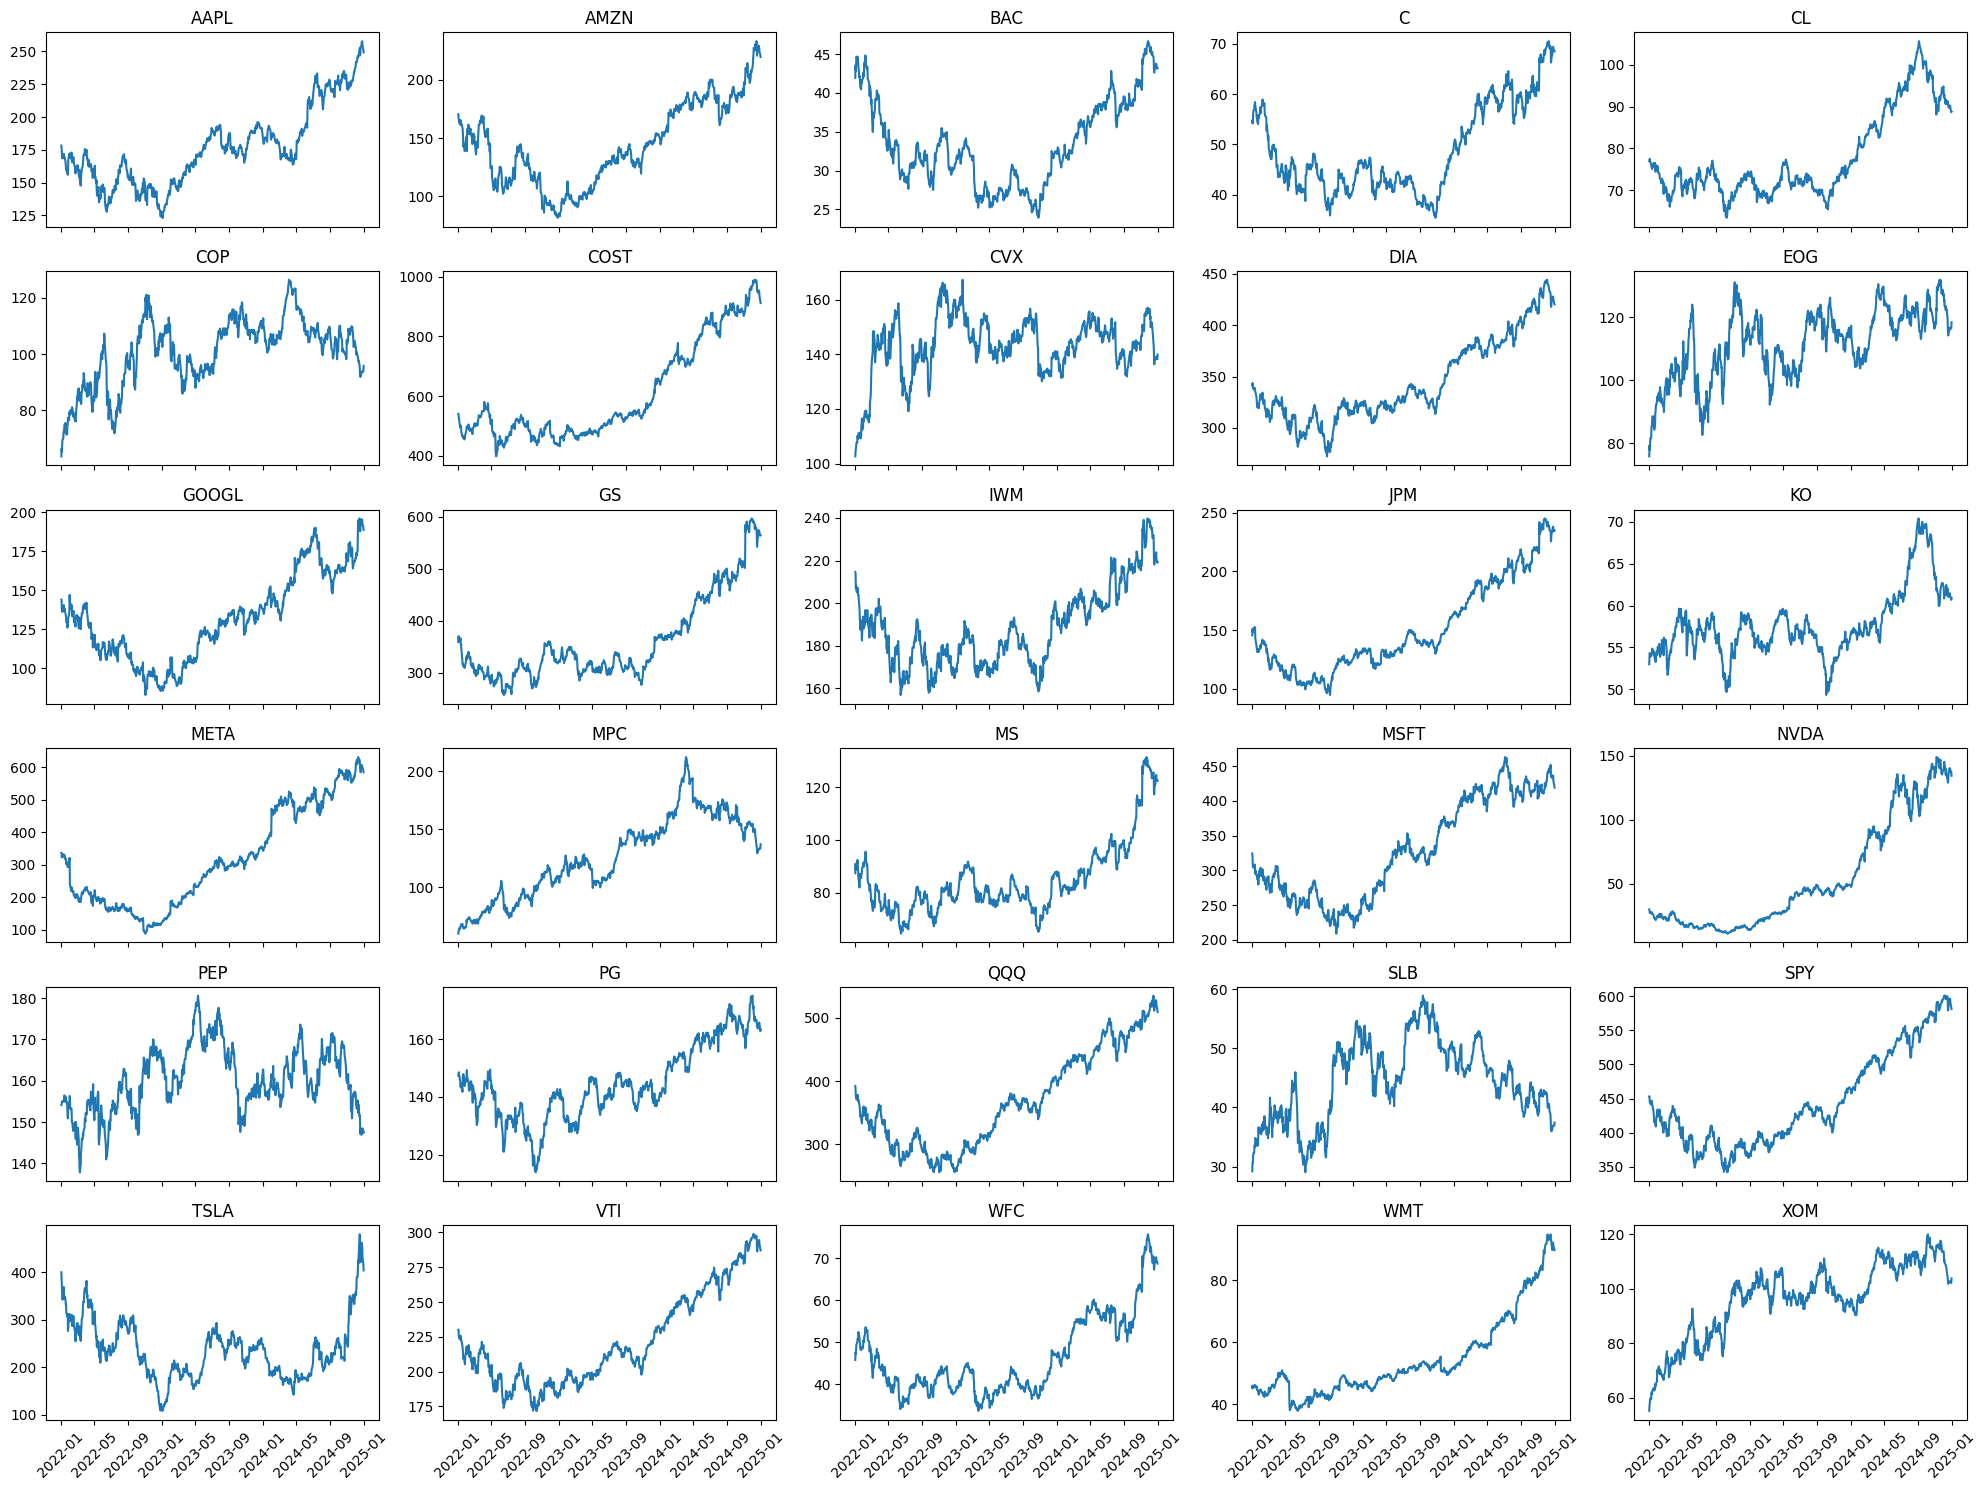

Figure 2. Prices of the 30 Stocks


In [57]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_historical_df.columns):
    ax.plot(close_historical_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Figure 2. Prices of the 30 Stocks")

# Baselines

To construct the baseline models (mean, naive, and seasonal naive) in a single figure, we first assessed whether seasonality was present across the stocks. As shown in Figure 3, there is no consistent or systematic seasonal pattern observable across the full set of assets. While a few stocks such as CVX and TSLA display indications of seasonality, these patterns are present all throughout. Given this inconsistency, we proceed by assuming a simplified seasonality of five business days for the baseline seasonal naive model.

We also implement a three-way data split consisting of training, validation, and test sets. The training and validation sets cover the period from January 2022 to January 2025, using an 80–20 split. The test set consists of the random 60-day period of observations consisting after January 2025.

Figure 3. ACF of the 30 Stocks


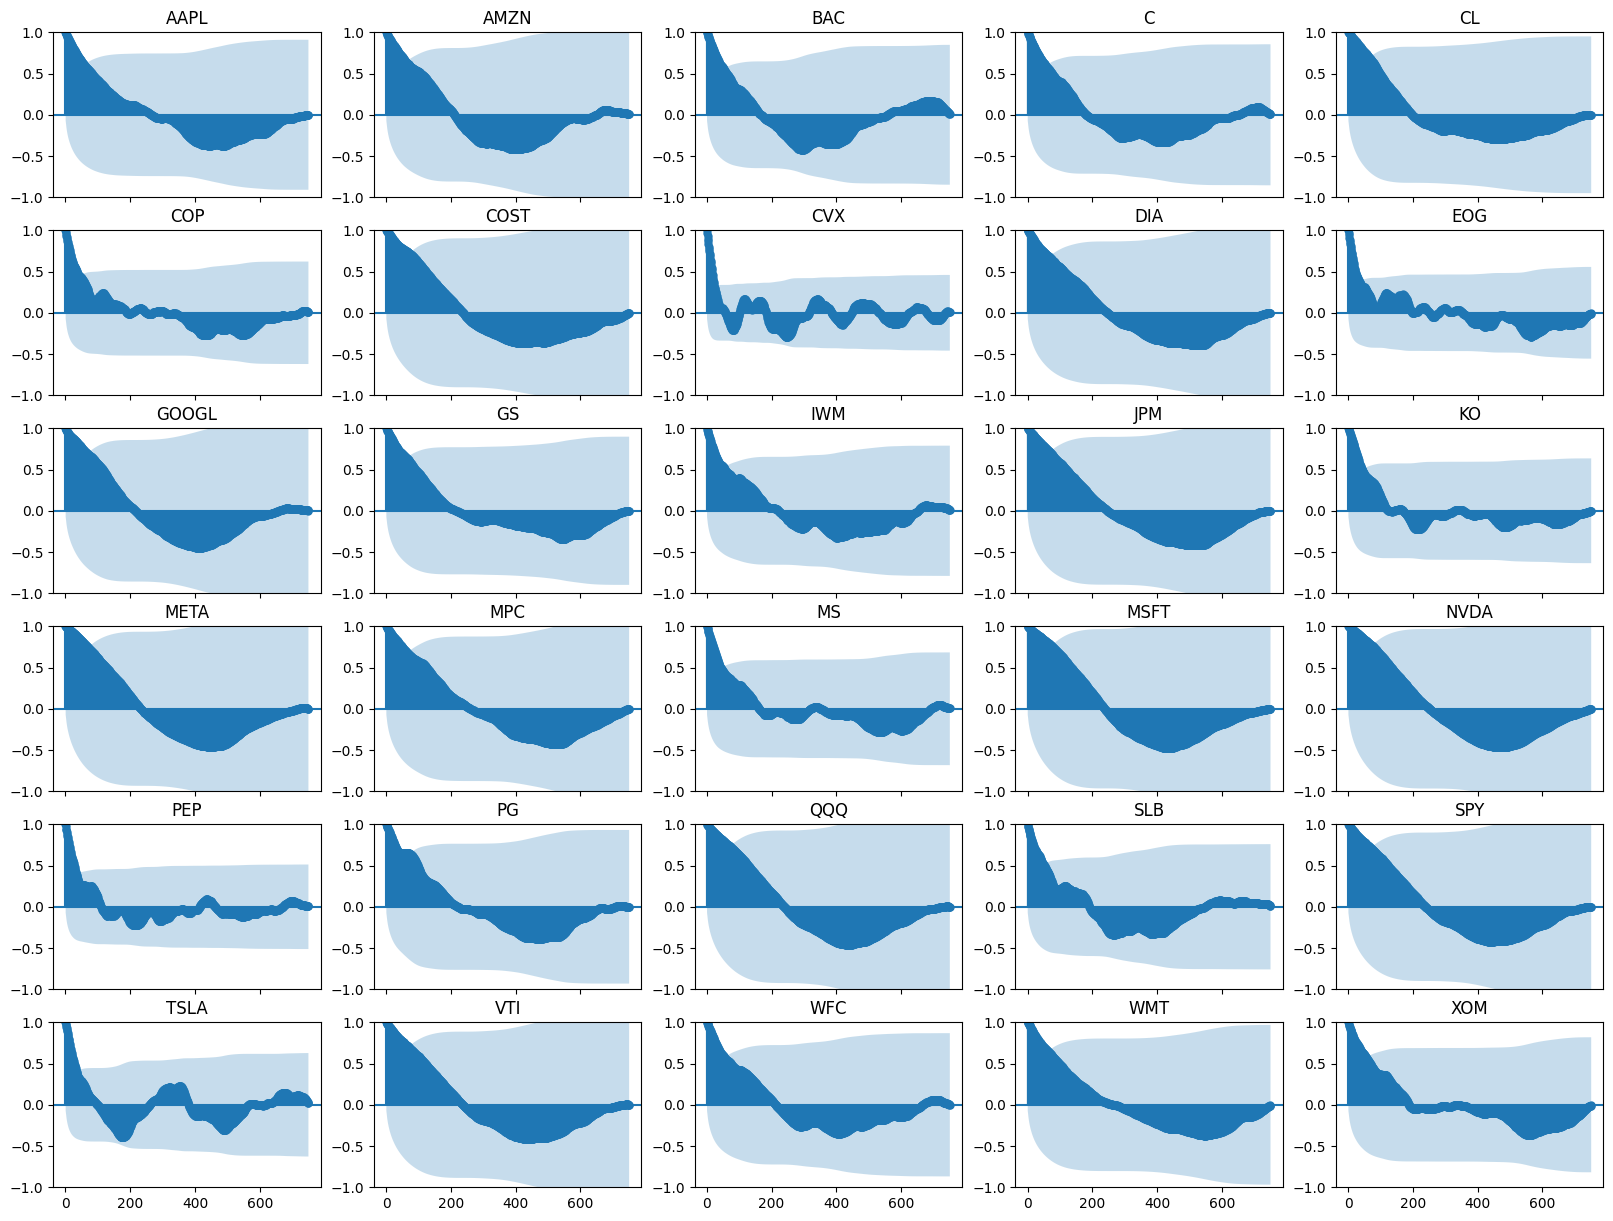

In [58]:
# Apply log
close_log_df = np.log(close_historical_df)

fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df.columns):
    plot_acf(close_log_df[stock], ax=ax, lags=750, title=stock)

print("Figure 3. ACF of the 30 Stocks")

In [59]:
# Create the train and test split
val_point = int(close_log_df.shape[0] * 0.8)
num_val = close_log_df.shape[0] - val_point
train_df = close_log_df.iloc[:val_point]
val_df = close_log_df.iloc[val_point:]

def forecast_seasonal_naive(df: pd.DataFrame, m: int = 5, horizon: int = num_val) -> pd.DataFrame:
    """
    Seasonal naïve forecasting model applied column-wise to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame where each column represents a univariate time series
        (e.g., multiple stock price series).
    m : int, optional (default=5)
        The assumed seasonality length. The model uses the last `m` observations
        of each column as the repeating seasonal pattern.
    horizon : int
        Number of future time steps to forecast.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing seasonal naïve forecasts for each column of `df`.
        Each column contains `horizon` forecasts derived from the last `m` values.
    """

    forecasts = {}

    for col in df.columns:
        # Extract last seasonal cycle for this column
        last_m_vals = df[col].iloc[-m:].values.ravel()

        # Repeat the pattern to fill the forecast horizon
        repeated_vals = np.tile(last_m_vals, horizon)[:horizon]

        # Store forecasts
        forecasts[col] = repeated_vals

    return pd.DataFrame(forecasts)

In [60]:
# mean forecasts
mean_forecast = pd.DataFrame([train_df.mean().values] * num_val, 
                             index=val_df.index, 
                             columns=val_df.columns)

# naive forecasts
naive_forecast = pd.DataFrame([train_df.iloc[-1].values] * num_val,
                              index=val_df.index,
                              columns=val_df.columns)

# seasonal naive forecasts
seasonal_naive_forecast = forecast_seasonal_naive(train_df, m = 5)
seasonal_naive_forecast.index = val_df.index

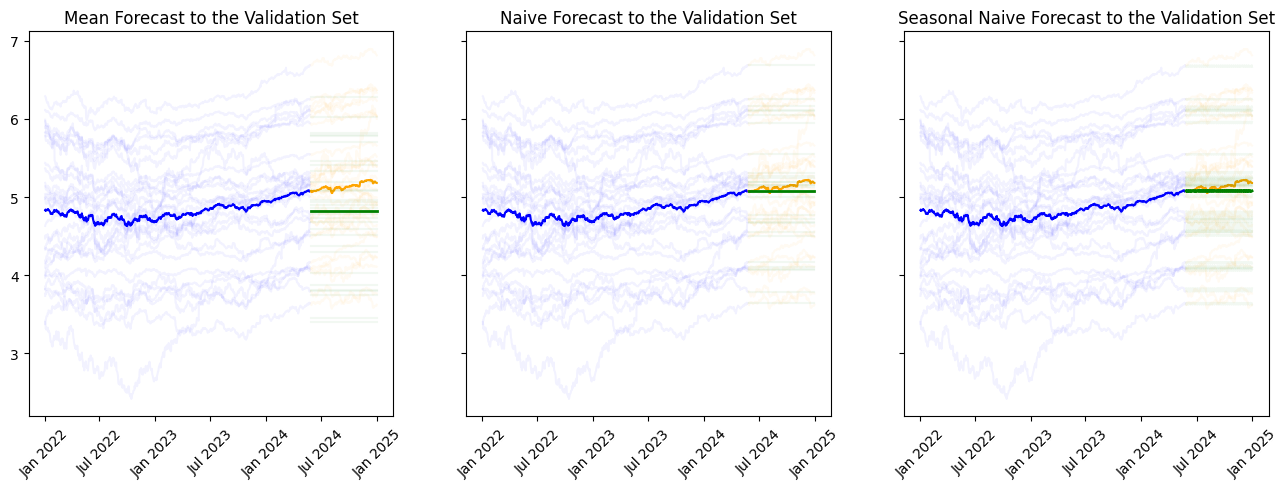

In [61]:

# Drawing time!
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

opacity_num = 0.05
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)
    ax.plot(train_df.mean(axis=1), color='blue')

    ax.plot(val_df, color='orange', alpha=opacity_num)
    ax.plot(val_df.mean(axis=1), color='orange', label='Val Median')

# Plot the mean
axs[0].plot(mean_forecast, label='Mean Forecast', color='green', alpha=opacity_num)
axs[0].plot(mean_forecast.mean(axis=1), label='Mean Forecast', linewidth=2, color='green')
axs[0].set_title('Mean Forecast to the Validation Set')

# plot the naive
axs[1].plot(naive_forecast, label='Naive Forecast', color='green', alpha=opacity_num)
axs[1].plot(naive_forecast.mean(axis=1), label='Naive Forecast', linewidth=2, color='green')
axs[1].set_title('Naive Forecast to the Validation Set')

# plot the Seasonal Naive
axs[2].plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', color='green', alpha=opacity_num)
axs[2].plot(seasonal_naive_forecast.mean(axis=1), label='Seasonal Naive Forecast', linewidth=2, color='green')
axs[2].set_title('Seasonal Naive Forecast to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels


In [62]:

# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock])
    }

# Convert to a DataFrame for readability
# We'll MultiIndex this to have stock -> baseline -> metric
df_list = []
for stock, metrics_dict in performance_stock.items():
    for baseline, metrics in metrics_dict.items():
        # metrics is assumed to be a dictionary {metric_name: value, ...}
        row = metrics.copy()
        row['Stock'] = stock
        row['Baseline'] = baseline
        df_list.append(row)

metrics_df = pd.DataFrame(df_list)
metrics_df = metrics_df.set_index(['Stock', 'Baseline'])

# Display
# This is the mean scores across the different stocks
metrics_df.groupby(level='Baseline').mean()

,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Baseline,,,,,,
Mean,0.321077,0.177515,0.331087,6.198289,6.564264,46.511112
Naive,0.089097,0.017392,0.108980,1.736799,1.762611,46.511112
Seasonal Naive,0.093134,0.018924,0.112645,1.819917,1.847516,51.088886


# ARIMA


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

### First thing to consider when creating an ARIMA model is testing the data for stationarity using the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin test.

In [65]:
warnings.filterwarnings("ignore")

# --- ADF Test Function ---
def adf_test_suite(timeseries):
    """
    Performs the Augmented Dickey-Fuller test on a time series.
    H0: The series is non-stationary.
    """
    # Use 'ct' for constant and trend since visual inspection (Figure 2) shows a clear trend
    result = adfuller(timeseries, autolag='AIC', regression='ct')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value <= 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'ADF Statistic': result[0],
        'ADF P-value': p_value,
        'ADF Lags Used': result[2],
        'ADF Conclusion (alpha=0.05)': is_stationary
    })

# --- KPSS Test Function ---
def kpss_test_suite(timeseries):
    """
    Performs the Kwiatkowski-Phillips-Schmidt-Shin test on a time series.
    H0: The series is trend-stationary.
    """
    # Use 'ct' for trend-stationarity (constant and trend)
    result = kpss(timeseries, regression='ct', nlags='auto')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value > 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'KPSS Statistic': result[0],
        'KPSS P-value': p_value,
        'KPSS Lags Used': result[2],
        'KPSS Conclusion (alpha=0.05)': is_stationary
    })

In [ ]:
# Difference only once
close_log_df1 = close_log_df.diff().dropna()

adf_results_df = close_log_df1.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df1.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

def consolidate_conclusion(row):
    adf_c = row['ADF Conclusion']
    kpss_c = row['KPSS Conclusion']
    
    if adf_c == 'Stationary' and kpss_c == 'Stationary':
        return 'Strictly Stationary (Strong Evidence)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Non-Stationary':
        return 'Non-Stationary (Strong Evidence)'
    elif adf_c == 'Stationary' and kpss_c == 'Non-Stationary':
        # ADF rejects Unit Root, KPSS rejects Trend-Stationary. Contradictory.
        # Often implies the series is difference stationary (needs differencing).
        return 'Difference Stationary (Requires Differencing)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Stationary':
        # ADF fails to reject Unit Root, KPSS fails to reject Trend-Stationary.
        # Often implies the series is trend stationary (needs detrending).
        return 'Trend Stationary (Requires Detrending)'
    else:
        return 'Inconclusive/Contradictory'

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
final_results

,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
AAPL,Stationary,Stationary,Strictly Stationary (Strong Evidence)
AMZN,Stationary,Stationary,Strictly Stationary (Strong Evidence)
BAC,Stationary,Stationary,Strictly Stationary (Strong Evidence)
C,Stationary,Stationary,Strictly Stationary (Strong Evidence)
CL,Stationary,Stationary,Strictly Stationary (Strong Evidence)
COP,Stationary,Stationary,Strictly Stationary (Strong Evidence)
COST,Stationary,Stationary,Strictly Stationary (Strong Evidence)
CVX,Stationary,Stationary,Strictly Stationary (Strong Evidence)
DIA,Stationary,Stationary,Strictly Stationary (Strong Evidence)


### We can see that NVDA and META may still need differencing, but we can check by graphing them first.

Ticker        META        NVDA
count   752.000000  752.000000
mean      0.000734    0.001990
std       0.031151    0.034430
min      -0.306391   -0.105412
25%      -0.011744   -0.018763
50%       0.000749    0.003264
75%       0.014362    0.021791
max       0.209307    0.218088
Ticker
META    0
NVDA    0
dtype: int64


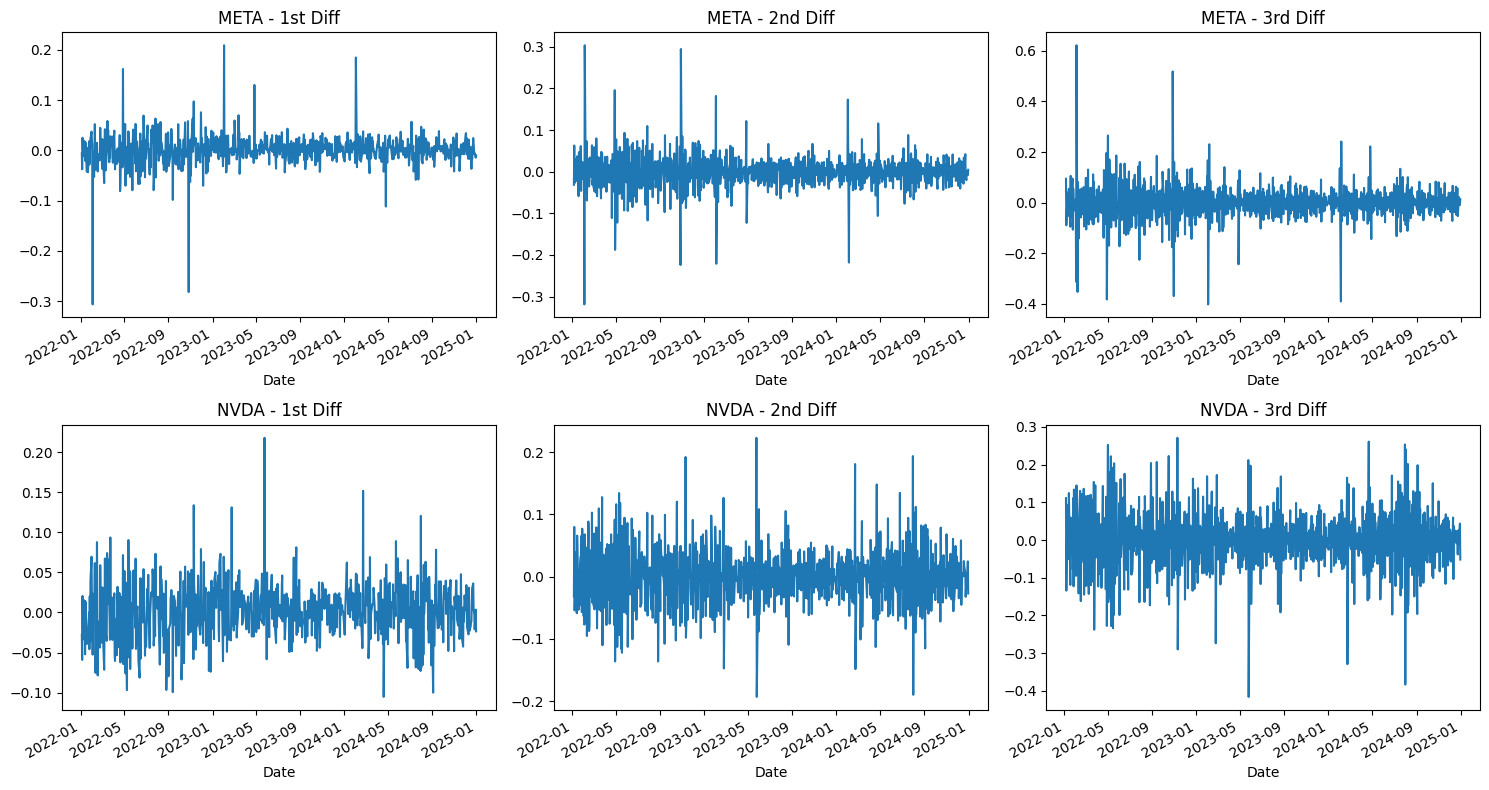

In [70]:
# Check META and NVDA data quality
print(close_log_df1[['META', 'NVDA']].describe())
print(close_log_df1[['META', 'NVDA']].isnull().sum())

# Plot the differenced series
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, stock in enumerate(['META', 'NVDA']):
    # Original log returns
    close_log_df1[stock].plot(ax=axes[i, 0], title=f'{stock} - 1st Diff')
    # 2nd difference
    close_log_df1[stock].diff().plot(ax=axes[i, 1], title=f'{stock} - 2nd Diff')
    # 3rd difference
    close_log_df1[stock].diff().diff().plot(ax=axes[i, 2], title=f'{stock} - 3rd Diff')
plt.tight_layout()
plt.show()

### Visually, the 1st order difference already looks stationary. There is also prevalent financial theory that log returns (1st difference in log price) is standard, overdifferencing may cause issues with noise.

### Optimal d = 1

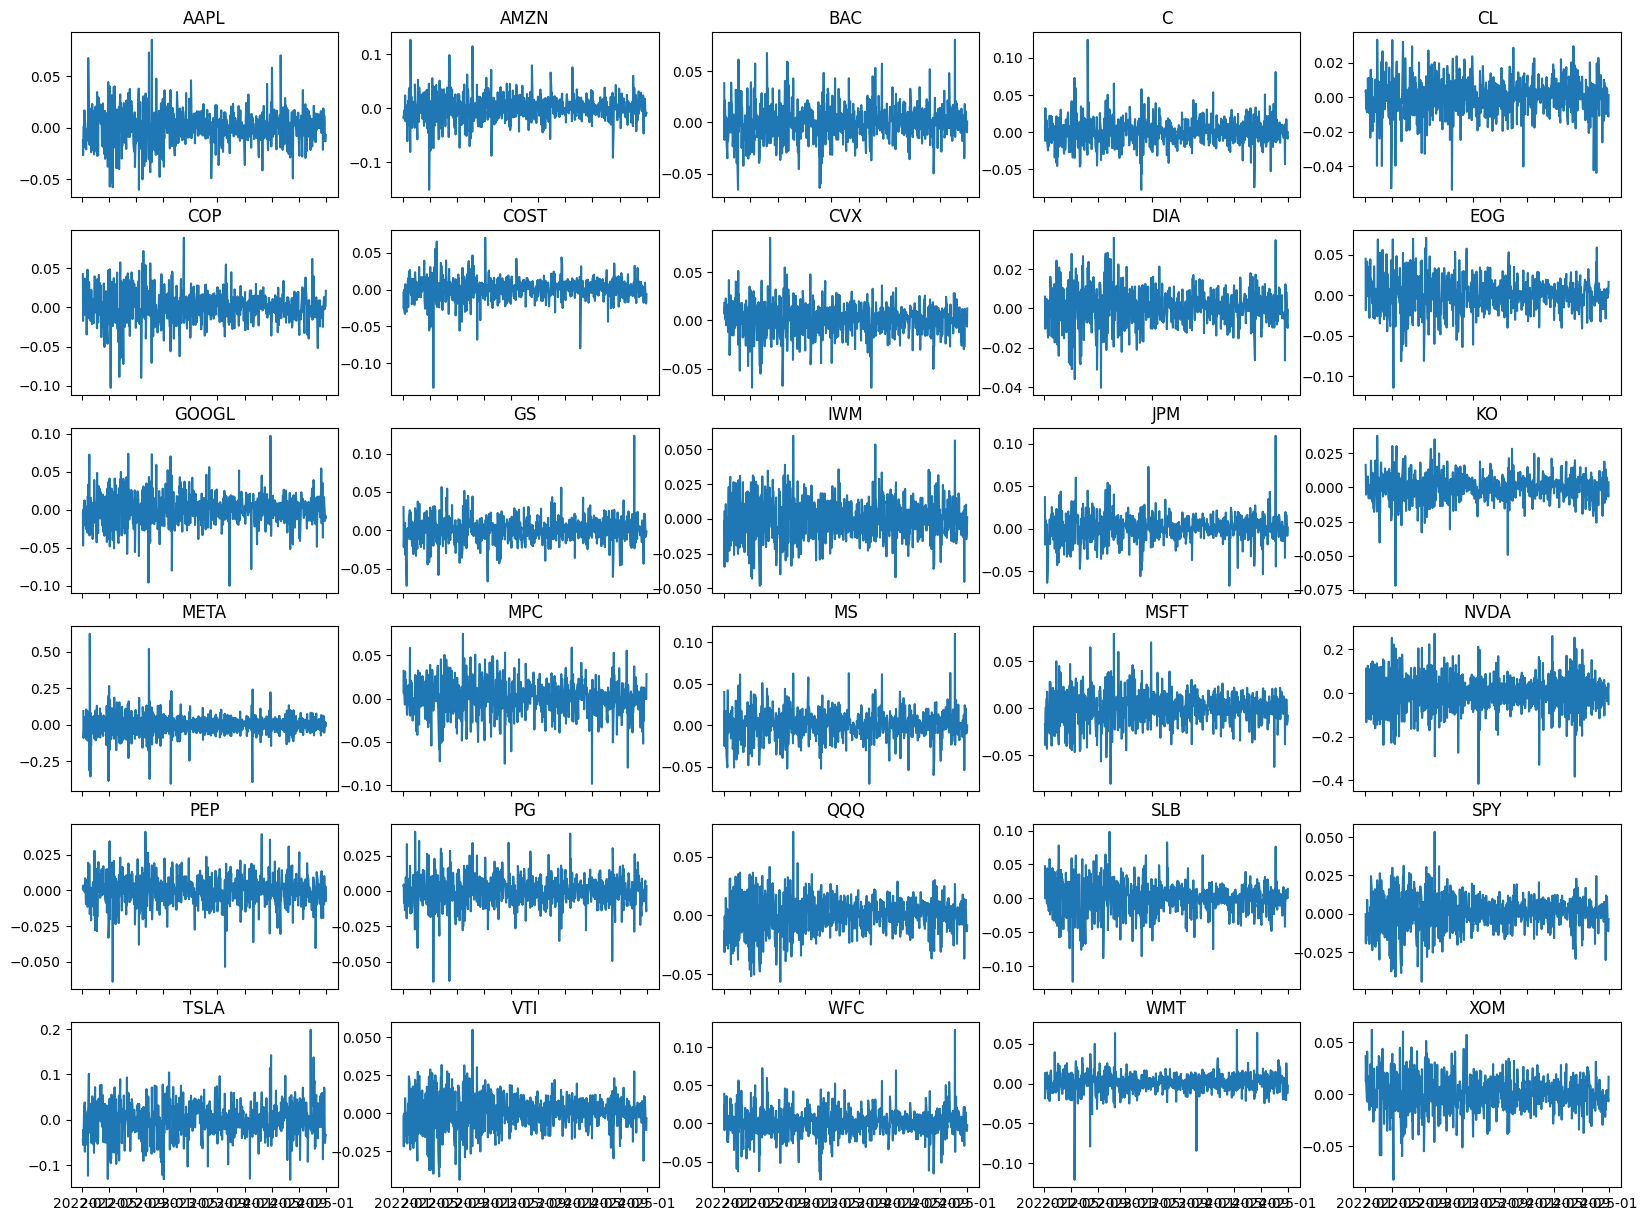

In [67]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    ax.plot(close_log_df1[stock], label=stock)
    ax.set_title(stock)



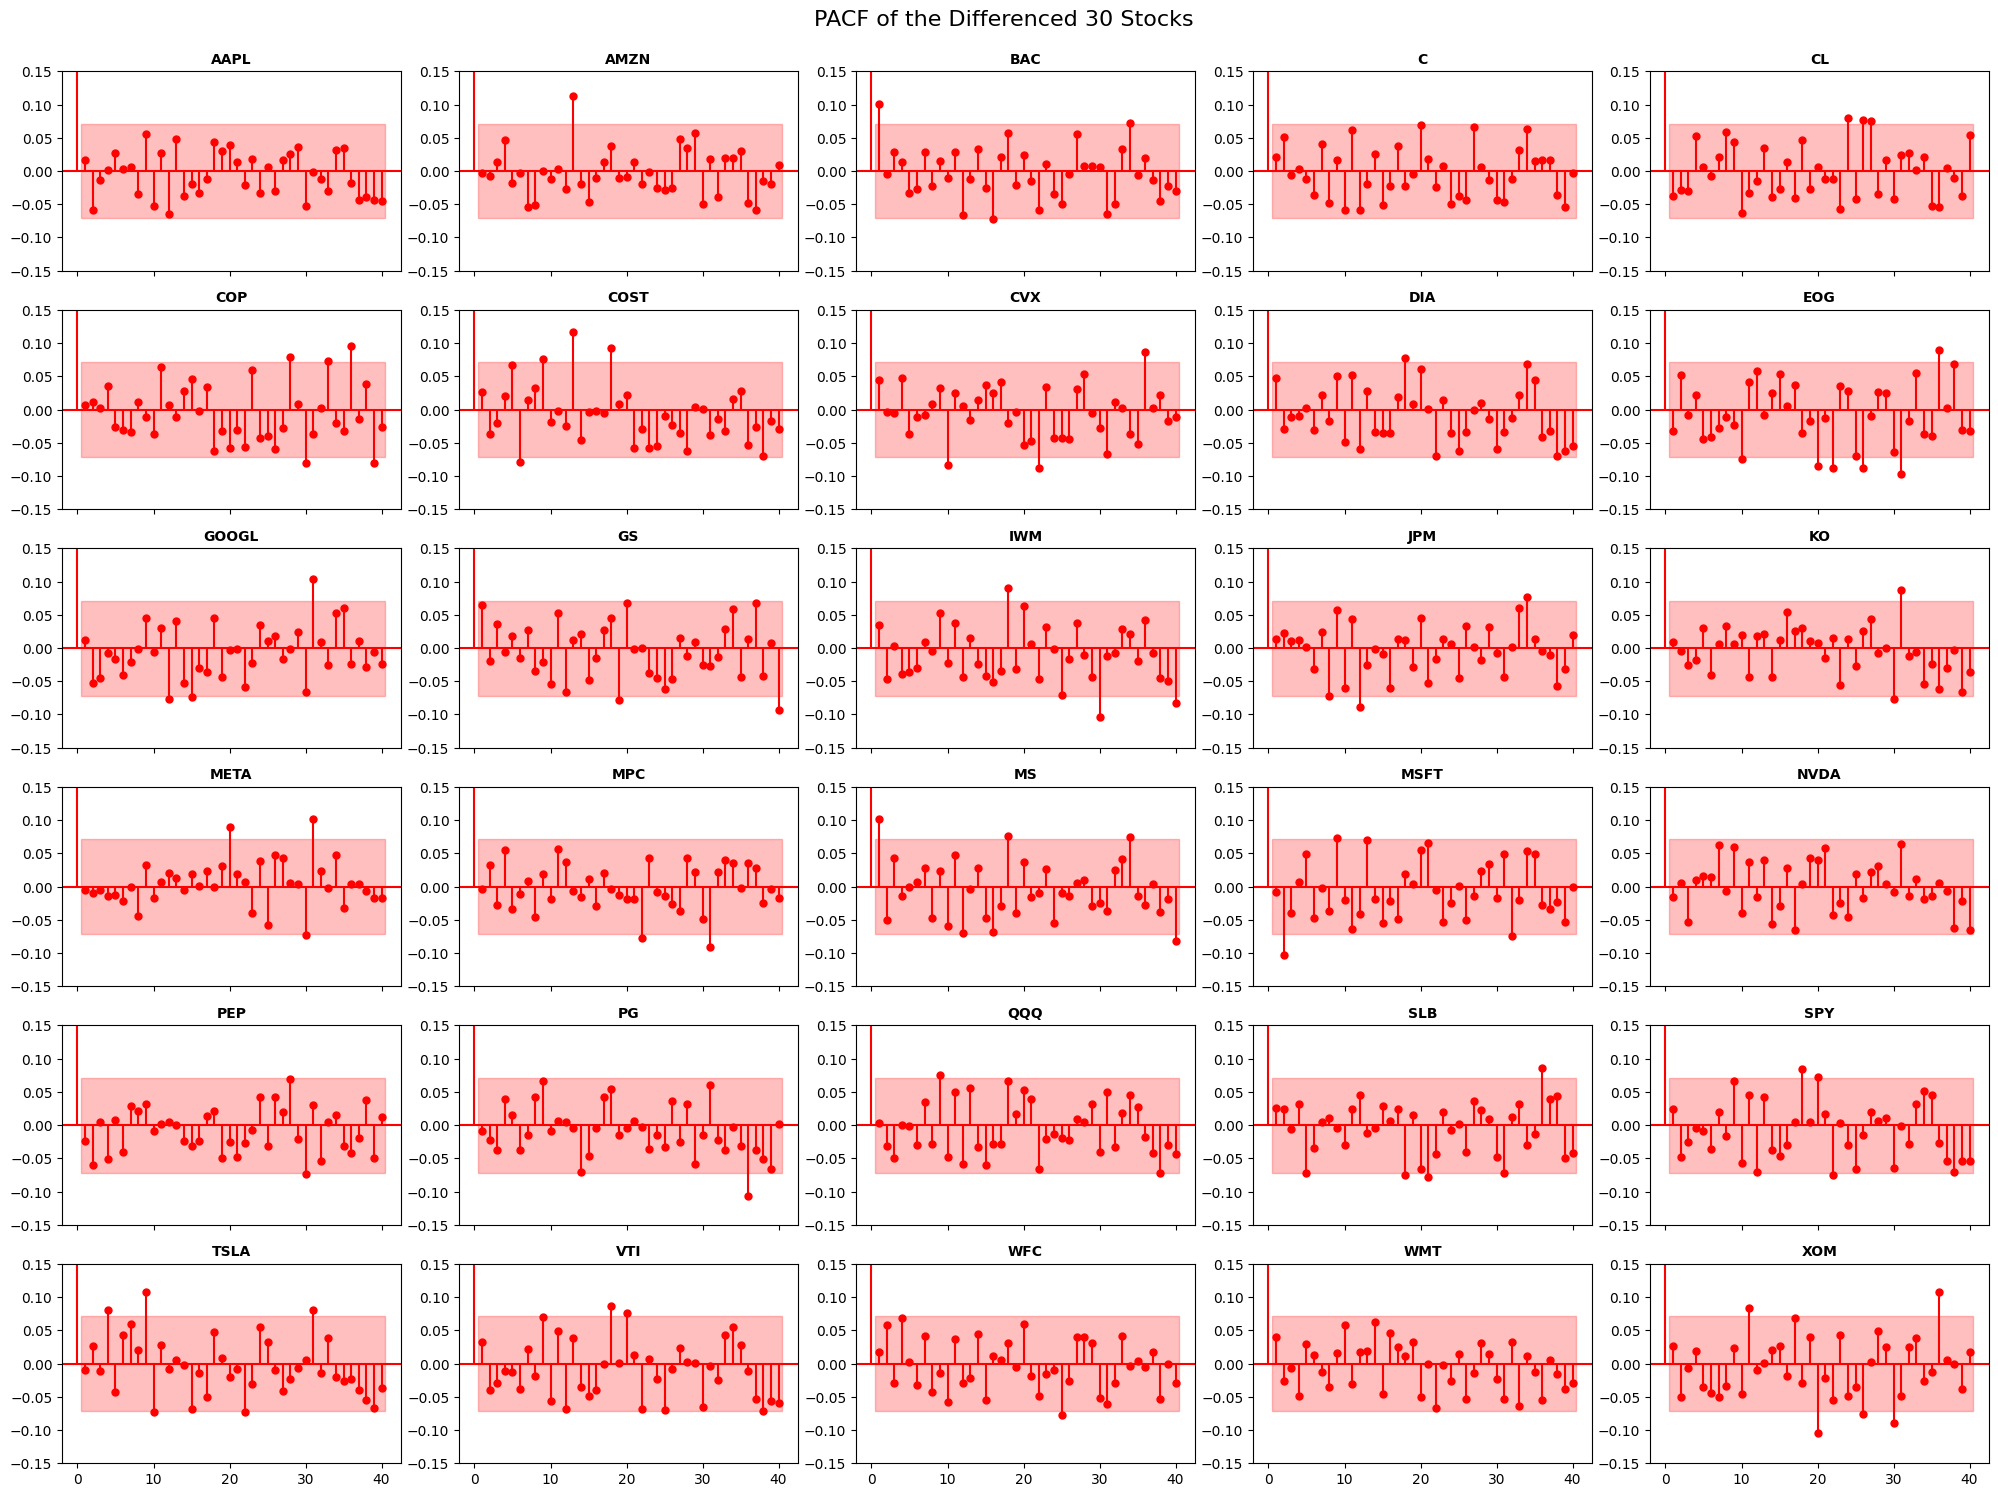

Figure: PACF of the differenced 30 Stocks


In [86]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot PACF
    plot_pacf(close_log_df1[stock].dropna(), ax=ax, lags=40, method='ywm')
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.15, 0.15)
    for item in ax.collections:
        item.set_color('red')
    for item in ax.lines:
        item.set_color('red')


# Add main title
fig.suptitle('PACF of the Differenced 30 Stocks', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("Figure: PACF of the differenced 30 Stocks")

### All of the stocks don't seem to show much autocorrelation after differencing, so

### Optimal p = 0

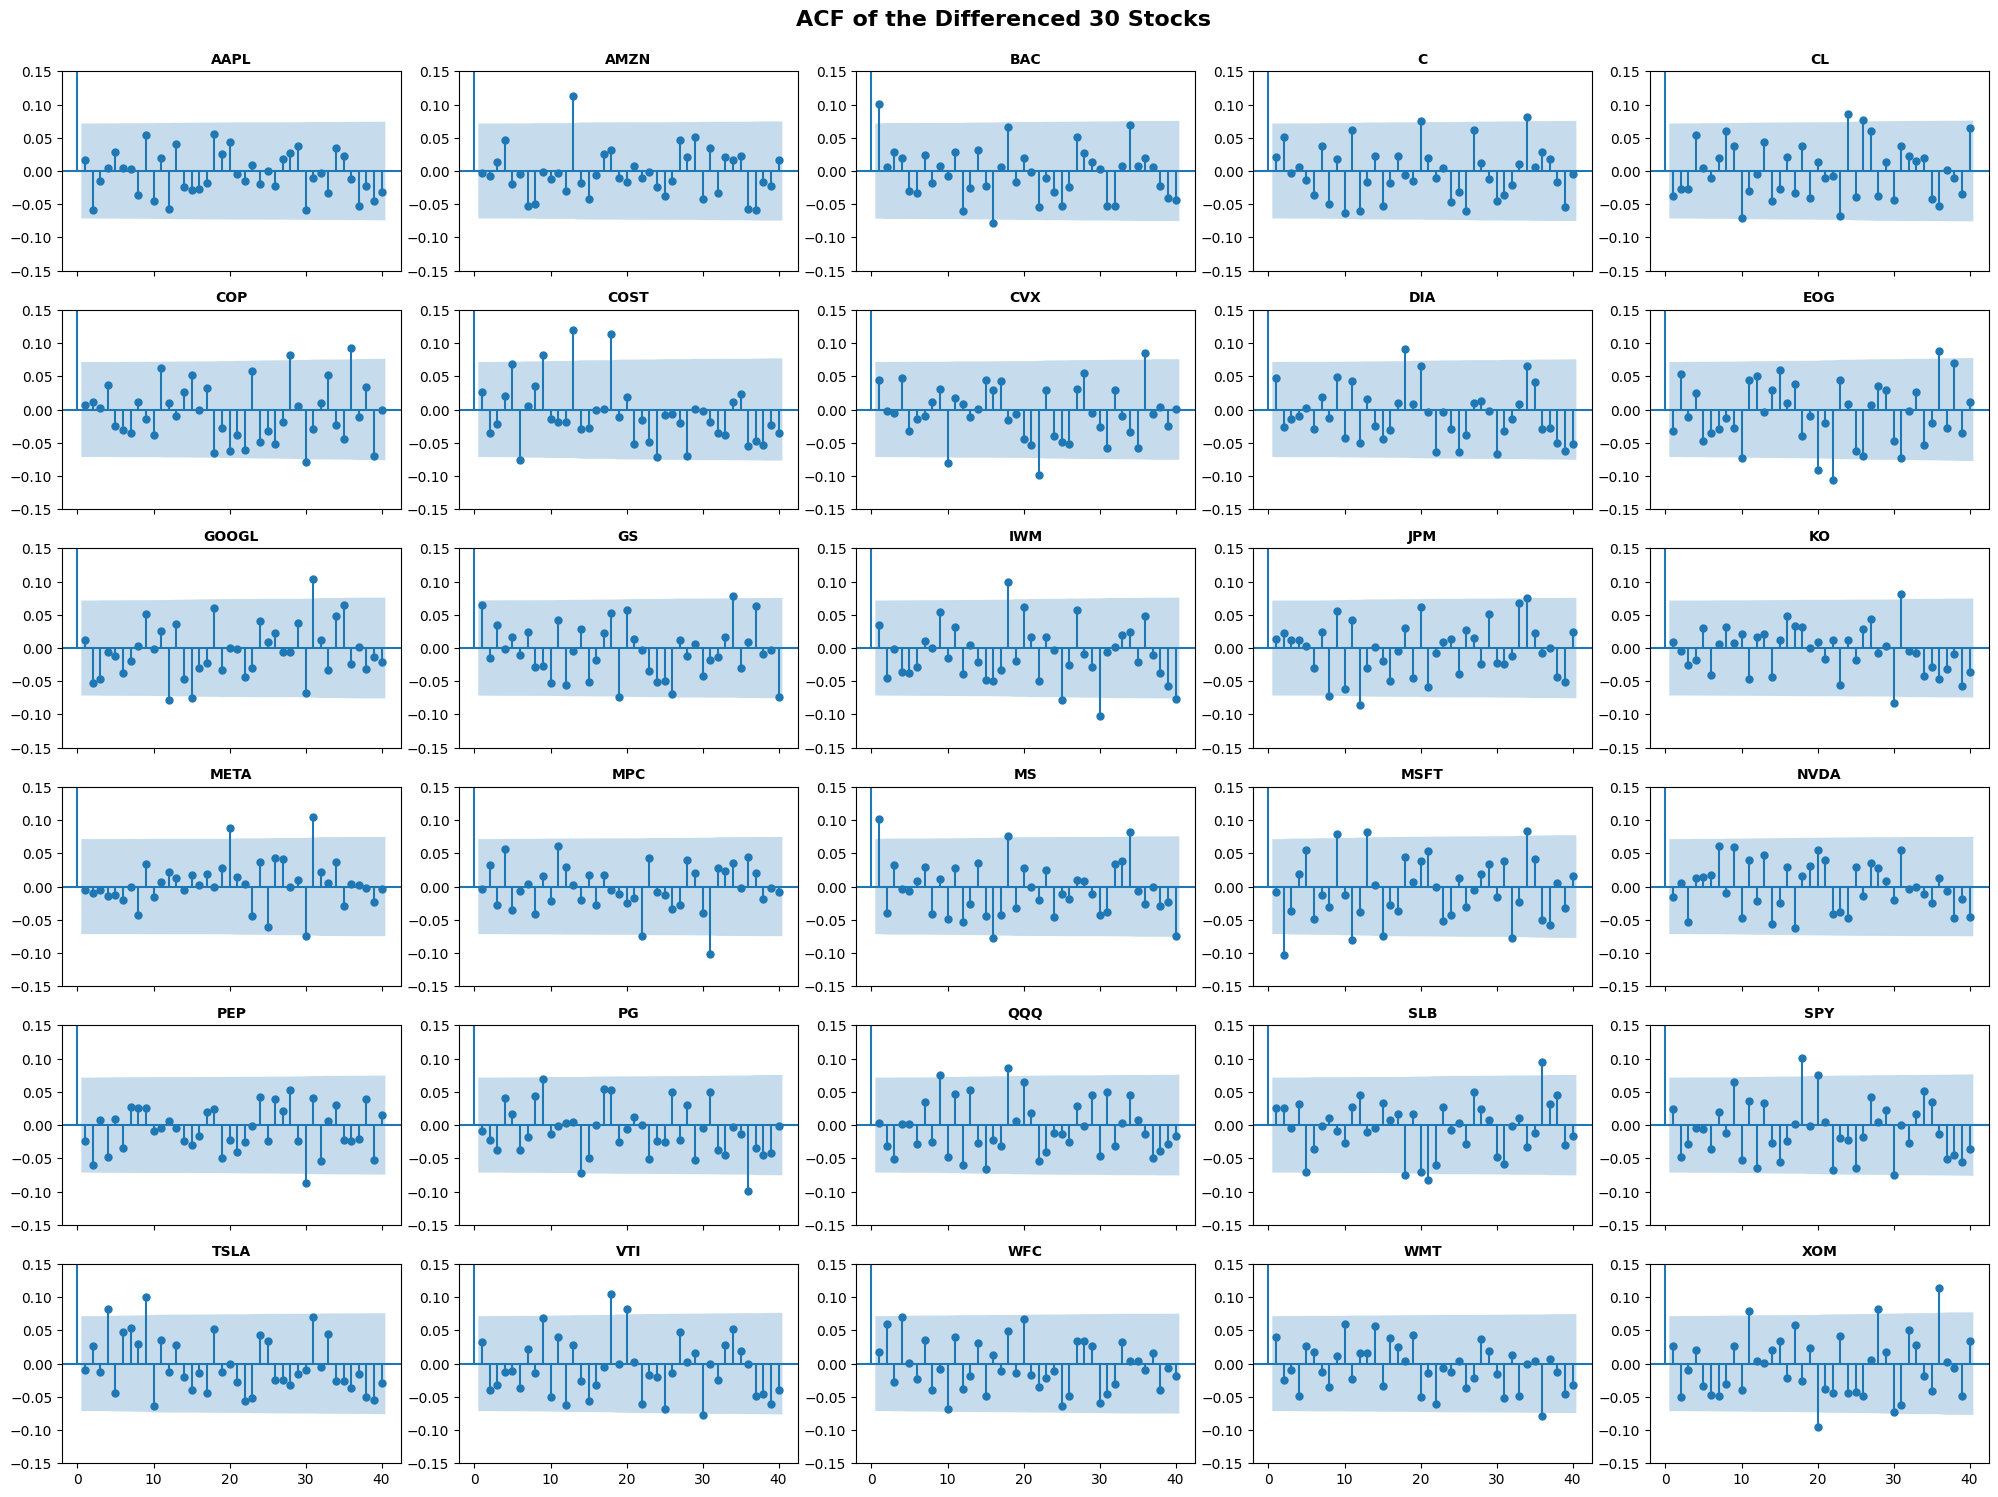

Figure: ACF of the differenced 30 Stocks


In [85]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot ACF
    plot_acf(close_log_df1[stock].dropna(), ax=ax, lags=40)
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.15, 0.15)

# Add main title
fig.suptitle('ACF of the Differenced 30 Stocks', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Figure: ACF of the differenced 30 Stocks")

### All of the stocks don't seem to show much autocorrelation after differencing, so

### Optimal q = 0, except for BAC and MS where q = 1

### We can also use Bayesian Information Criterion (BIC) to help us confirm what is the most optimal (p,q) combination

In [100]:
from statsmodels.tsa.arima.model import ARIMA


# Store results for all stocks
all_results = []

# Test different orders for each stock
for stock in close_log_df1.columns:
    results = {}
    
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                model = ARIMA(close_log_df1[stock].dropna(), order=(p, 0, q))
                fitted = model.fit()
                results[(p, q)] = fitted.bic
            except Exception as e:
                # Skip models that fail to converge
                continue
    
    # Check if any models succeeded
    if len(results) > 0:
        best_model = min(results, key=results.get)
        all_results.append({
            'Stock': stock,
            'Optimal p': best_model[0],
            'Optimal q': best_model[1],
            'BIC': results[best_model]
        })
    else:
        all_results.append({
            'Stock': stock,
            'Optimal p': None,
            'Optimal q': None,
            'BIC': None
        })




In [93]:
# Create and display DataFrame
bic_results_df = pd.DataFrame(all_results)
print("\nOptimal ARIMA Orders by BIC:")
bic_results_df



Optimal ARIMA Orders by BIC:


,Stock,Optimal p,Optimal q,BIC
0,AAPL,0,0,-3978.436594
1,AMZN,0,0,-3453.401723
2,BAC,0,1,-3955.827203
3,C,0,0,-3905.299274
4,CL,0,0,-4639.986019
5,COP,0,0,-3697.854340
6,COST,0,0,-4155.817235
7,CVX,0,0,-4049.411613
8,DIA,0,0,-4893.485425
9,EOG,0,0,-3649.761469


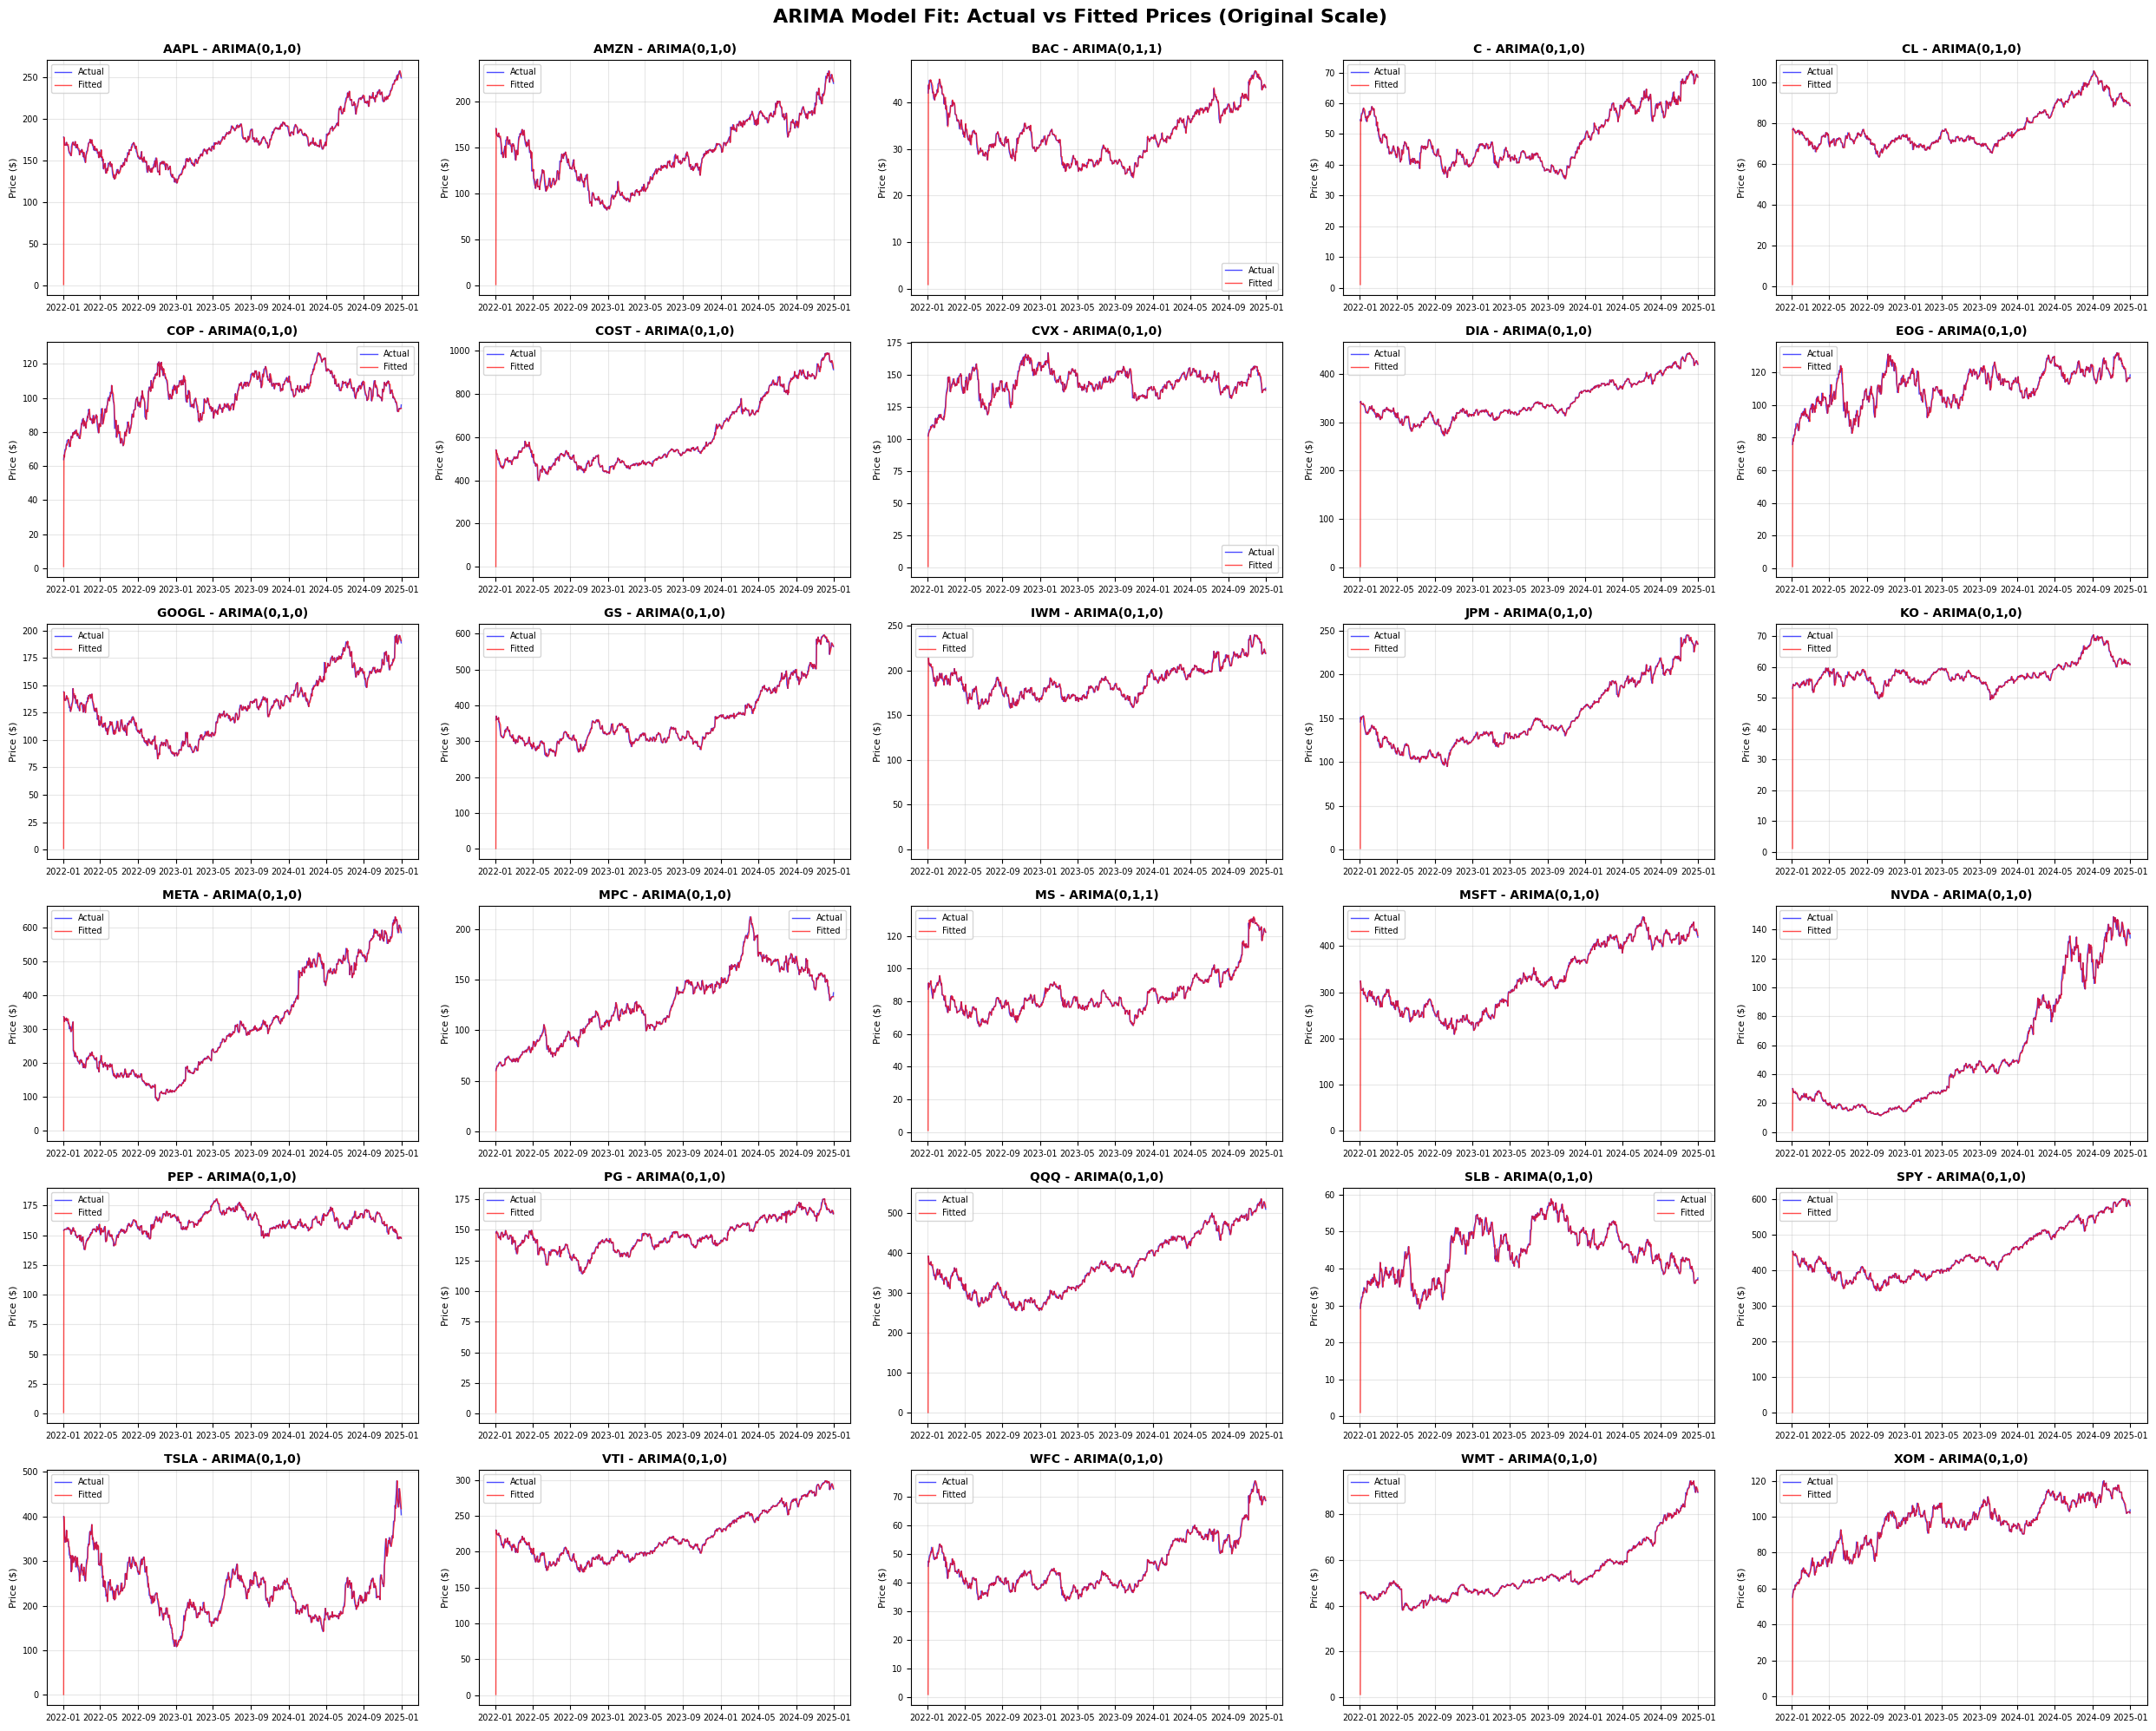

Figure: ARIMA model fitted values vs actual prices (non-differenced)


In [99]:
# Create subplots for all 30 stocks
fig, axs = plt.subplots(6, 5, figsize=(25, 20))

for ax, (_, row) in zip(axs.flatten(), bic_results_df.iterrows()):
    stock = row['Stock']
    p = int(row['Optimal p'])
    q = int(row['Optimal q'])
    
    try:
        # Get the original log prices (before differencing)
        original_data = close_historical_df[stock].dropna()
        log_data = np.log(original_data)
        
        # Fit ARIMA model with d=1 (since we need to difference)
        model = ARIMA(log_data, order=(p, 1, q))
        fitted_model = model.fit()
        
        # Get fitted values (in log scale)
        fitted_log = fitted_model.fittedvalues
        
        # Convert back to original price scale
        fitted_prices = np.exp(fitted_log)
        
        # Plot actual vs fitted in original price scale
        ax.plot(original_data.index, original_data.values, 
                label='Actual', color='blue', alpha=0.7, linewidth=1)
        ax.plot(fitted_prices.index, fitted_prices.values, 
                label='Fitted', color='red', alpha=0.7, linewidth=1)
        
        ax.set_title(f'{stock} - ARIMA({p},1,{q})', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_ylabel('Price ($)', fontsize=8)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'{stock}\nModel failed\n{str(e)[:30]}', 
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_title(f'{stock}', fontsize=10, fontweight='bold')

fig.suptitle('ARIMA Model Fit: Actual vs Fitted Prices (Original Scale)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Figure: ARIMA model fitted values vs actual prices (non-differenced)")

In [ ]:
def train_and_forecast_arima(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    bic_results_df: pd.DataFrame,
    num_val: int
) -> pd.DataFrame:
    """
    Train ARIMA(p,1,q) models using optimal p and q, then forecast the next num_val steps.
    """

    import warnings
    warnings.filterwarnings("ignore")

    # Ensure Stock is index
    bic_results_df = bic_results_df.set_index("Stock")

    # Prepare forecast container — same index as validation set
    arima_forecasts = pd.DataFrame(index=val_df.index, columns=val_df.columns)

    # Iterate through each stock
    for stock in train_df.columns:

        # Check if stock has BIC results
        if stock not in bic_results_df.index:
            print(f"Warning: No optimal orders found for {stock}. Skipping.")
            arima_forecasts[stock] = np.nan
            continue

        try:
            # Extract optimal p, q (ensure INT)
            p = int(bic_results_df.loc[stock, "Optimal p"])
            q = int(bic_results_df.loc[stock, "Optimal q"])
            order = (p, 1, q)

            # Fit ARIMA
            model = ARIMA(train_df[stock], order=order).fit()

            # Generate forecast using get_forecast (more robust than predict)
            forecast_obj = model.get_forecast(steps=num_val)
            forecast = forecast_obj.predicted_mean

            # Align forecast index to validation index
            forecast.index = val_df.index

            # Store
            arima_forecasts[stock] = forecast

        except Exception as e:
            print(f"Error fitting/forecasting ARIMA for {stock}: {e}")
            arima_forecasts[stock] = np.nan

    return arima_forecasts


In [ ]:
arima_forecasts_df = train_and_forecast_arima(
    train_df, 
    val_df, 
    bic_results_df, 
    num_val
    )

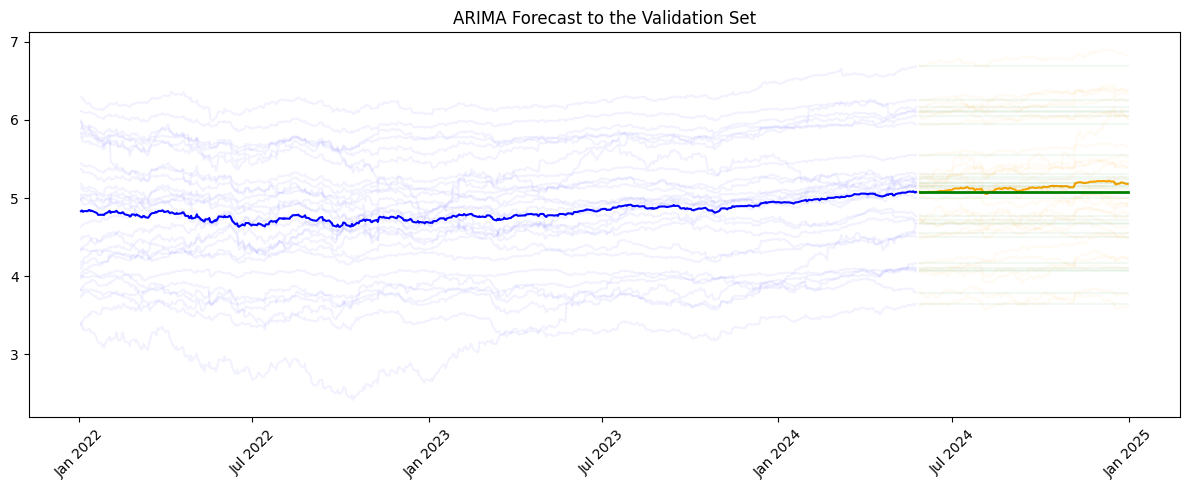

In [123]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.05

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(arima_forecasts_df, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(arima_forecasts_df.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

ax.set_title('ARIMA Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [127]:

# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock]),
        'ARIMA': ForecastingMetrics.compute_all_metrics(val_df[stock], arima_forecasts_df[stock])
    }

# Convert to a DataFrame for readability
# We'll MultiIndex this to have stock -> baseline -> metric
df_list = []
for stock, metrics_dict in performance_stock.items():
    for baseline, metrics in metrics_dict.items():
        # metrics is assumed to be a dictionary {metric_name: value, ...}
        row = metrics.copy()
        row['Stock'] = stock
        row['Baseline'] = baseline
        df_list.append(row)

metrics_df = pd.DataFrame(df_list)
metrics_df = metrics_df.set_index(['Stock', 'Baseline'])

# Display
# This is the mean scores across the different stocks
metrics_df.groupby(level='Baseline').mean()

,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Baseline,,,,,,
ARIMA,0.089058,0.017383,0.108935,1.735823,1.761602,46.511112
Mean,0.321077,0.177515,0.331087,6.198289,6.564264,46.511112
Naive,0.089097,0.017392,0.108980,1.736799,1.762611,46.511112
Seasonal Naive,0.093134,0.018924,0.112645,1.819917,1.847516,51.088886


### As expected, it performed similarly to Naive and Seasonal Naive, because Stock price data perform similarly to a random walk.

# VAR